# 🏠 Predicting House Prices in King County, Seattle, Washington

## Introduction

This project aims to predict house prices in **King County, Washington**, including Seattle, using housing data from homes sold between May 2014 and May 2015.

The analysis uses property characteristics such as bedrooms, bathrooms, living area, condition, grade, location-related information, and construction year.

A **Linear Regression** model is used to estimate house prices. The workflow includes exploratory data analysis, data preparation, feature engineering, model training, evaluation, and visualization of prediction results.

## Data Dictionary

| Column | Description |
| --- | --- |
| id | Unique identification number for a house |
| date | Date when the house was sold |
| price | Sale price of the house |
| bedrooms | Number of bedrooms |
| bathrooms | Number of bathrooms |
| sqft_living | Living area in square feet |
| sqft_lot | Lot area in square feet |
| floors | Number of floors |
| waterfront | Indicates whether the property has a waterfront view |
| view | Number of times the property was viewed |
| condition | Overall condition of the house |
| grade | Overall grade based on construction and design quality |
| sqft_above | Living area above ground |
| sqft_basement | Basement area in square feet |
| yr_built | Year the house was built |
| yr_renovated | Year the house was renovated |
| zipcode | ZIP code of the property |
| lat | Latitude |
| long | Longitude |
| sqft_living15 | Living area of the nearest 15 neighboring houses |
| sqft_lot15 | Lot area of the nearest 15 neighboring houses |

## Import Libraries

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## Load Dataset

In [26]:
df = pd.read_csv("kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Exploratory Data Analysis

In [27]:
df.shape

(21613, 21)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [29]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [30]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Correlation Analysis

The correlation matrix provides an overview of the relationships between numerical variables and house prices.

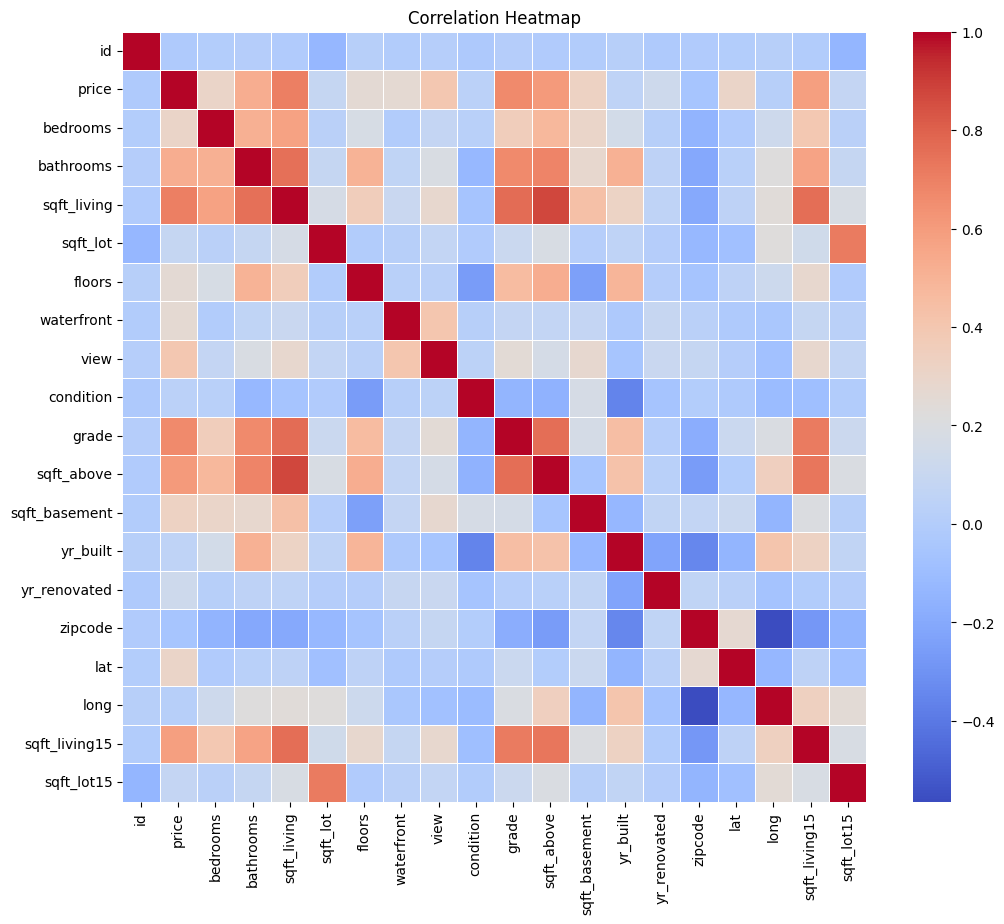

In [31]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

## Data Preparation

The `id` column does not provide useful information for house price prediction and is removed before modeling

In [32]:
df.drop(columns=["id"], inplace=True)

A new `age` feature is created from the construction year

In [33]:
df["sale_year"] = pd.to_datetime(df["date"]).dt.year
df["age"] = df["sale_year"] - df["yr_built"]

### Outlier Removal

Extreme values can strongly influence a regression model.  
The 97th percentile is used as a simple threshold for selected variables.

In [34]:
outliers = df.quantile(q=0.97, numeric_only=True)

df = df[df["price"] < outliers["price"]]
df = df[df["bedrooms"] < outliers["bedrooms"]]
df = df[df["bathrooms"] < outliers["bathrooms"]]
df = df[df["sqft_living"] < outliers["sqft_living"]]

df.shape

(18519, 22)

### Feature Transformation

The original project gives additional weight to bedrooms, bathrooms, and living area by squaring these values.

In [35]:
df["bedrooms"] = df["bedrooms"] ** 2
df["bathrooms"] = df["bathrooms"] ** 2
df["sqft_living"] = df["sqft_living"] ** 2

ZIP code is treated as a categorical feature.

Renovation and basement information are converted into binary variables:

- `1` = present
- `0` = not present

In [36]:
df["zipcode"] = df["zipcode"].astype("category")

df["yr_renovated"] = np.where(df["yr_renovated"] > 0, 1, 0)
df["sqft_basement"] = np.where(df["sqft_basement"] > 0, 1, 0)

## Data Visualization

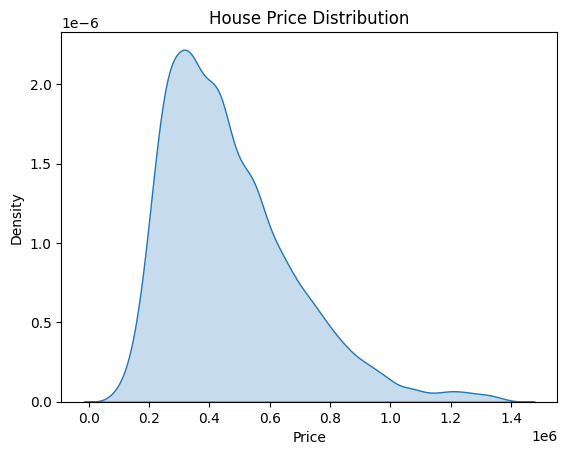

In [37]:
sns.kdeplot(x=df["price"], fill=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.show()

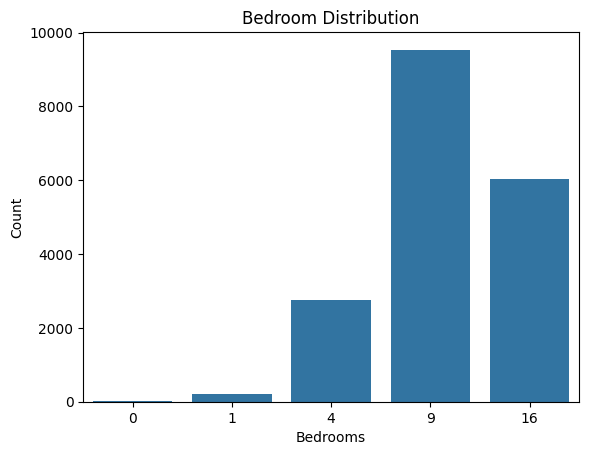

In [38]:
sns.countplot(x=df["bedrooms"])

plt.title("Bedroom Distribution")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

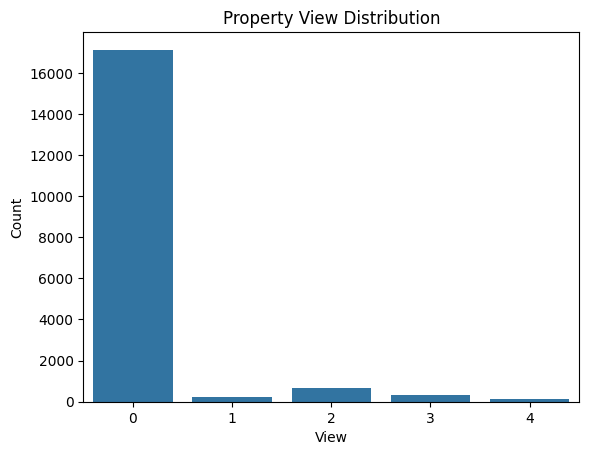

In [39]:
sns.countplot(x=df["view"])

plt.title("Property View Distribution")
plt.xlabel("View")
plt.ylabel("Count")
plt.show()

## Feature Engineering

In [40]:
abs(
    df.corr(numeric_only=True)["price"]
    .sort_values(ascending=False)
)

price            1.000000
grade            0.613276
sqft_living      0.600603
sqft_living15    0.550073
sqft_above       0.490733
lat              0.427376
bathrooms        0.400087
view             0.279914
bedrooms         0.263712
floors           0.241076
sqft_basement    0.164835
yr_renovated     0.100101
waterfront       0.097837
sqft_lot         0.075785
condition        0.066155
sqft_lot15       0.065667
long             0.022943
yr_built         0.010752
sale_year        0.003744
age              0.010691
Name: price, dtype: float64

The target variable is `price`.

The `date` column is removed before modeling, and categorical variables are converted into dummy variables.

In [41]:
x = df.drop(["price", "date"], axis=1)
y = df["price"]

x = pd.get_dummies(x, drop_first=True)

x.shape

(18519, 88)

## Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

Training set: (14815, 88)
Test set: (3704, 88)


## Modeling

A **Linear Regression** model is used because the target variable, house price, is continuous.

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

## Model Evaluation

In [44]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
mae = mean_absolute_error(y_test, predictions)

print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))

R² Score: 0.4475
RMSE: 158321.39
MAE: 124644.85


### Actual vs Predicted Prices

A scatter plot is used to compare the actual house prices with the model predictions.

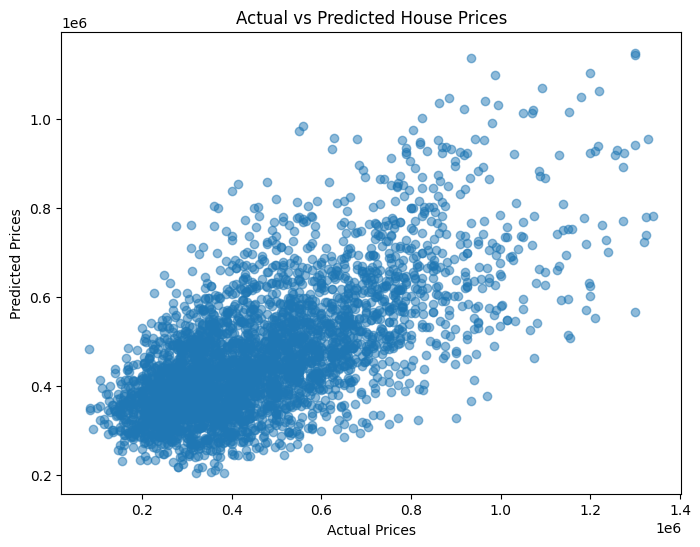

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Residual Analysis

Residuals show the difference between the actual and predicted house prices.

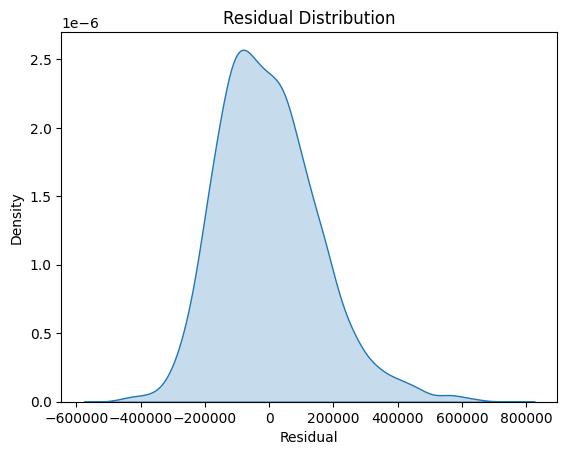

In [46]:
residuals = y_test - predictions

sns.kdeplot(x=residuals, fill=True)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

## Conclusion

This project applies **Linear Regression** to predict house prices in King County, Washington.

The workflow includes exploratory data analysis, outlier removal, feature transformation, categorical encoding, train-test splitting, regression modeling, and model evaluation.

The final model achieved:

- **R² Score:** 0.4475
- **RMSE:** 158,321.39
- **MAE:** 124,644.85

The results indicate that the model explains approximately 45% of the variation in house prices. The remaining prediction error suggests that house prices depend on more complex relationships that are not fully captured by a linear regression model.

Overall, the project presents a structured regression workflow for house price prediction and provides a baseline for further model improvement.